# install libraries

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 14.2 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 18.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 21.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 35.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 38.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━

## Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

## Load Datasets

In [3]:
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID","Brand","Sentiment","Tweet"]
)
df.head()

,ID,Brand,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## Data Cleaning

In [4]:

df = df.dropna()


df = df.drop_duplicates()

In [6]:
df.shape

(71656, 4)

##  Sentiment Distribution

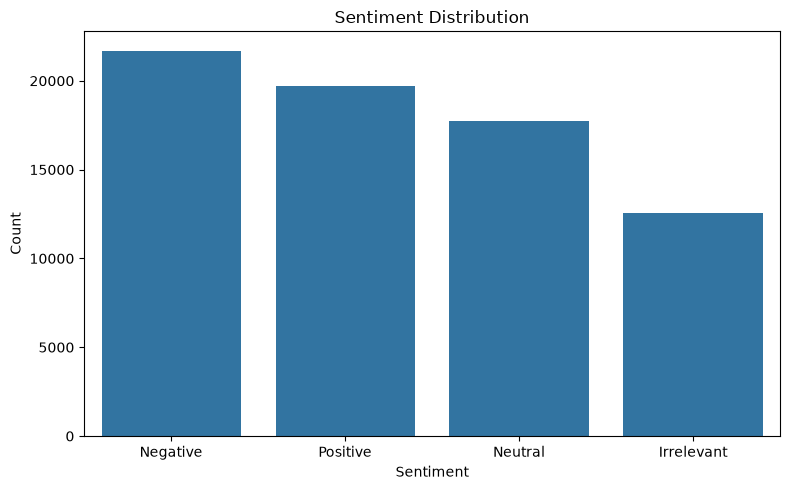

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("sentiment_distribution.png")
plt.show()

# Top Mentioned Brands

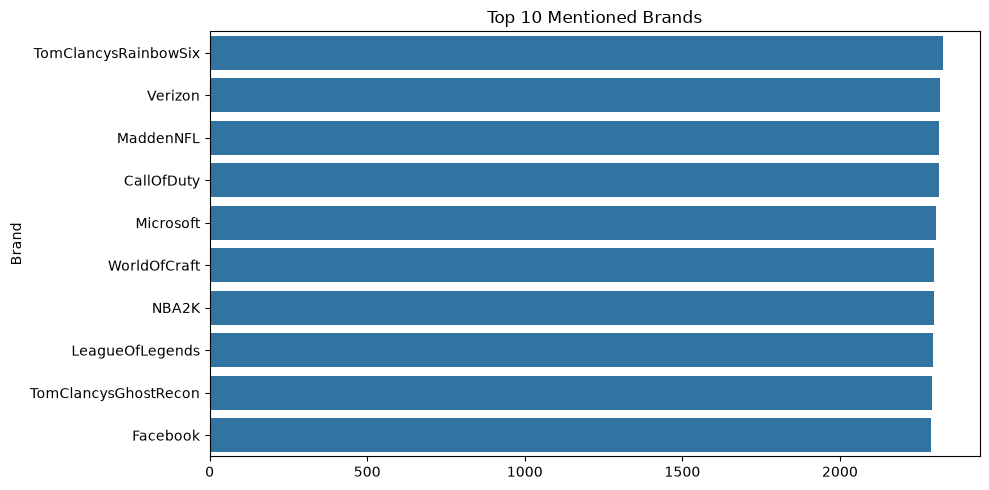

In [8]:
top_brands = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 10 Mentioned Brands")

plt.tight_layout()

plt.savefig("top_brands.png")
plt.show()

# Sentiment by  Brand

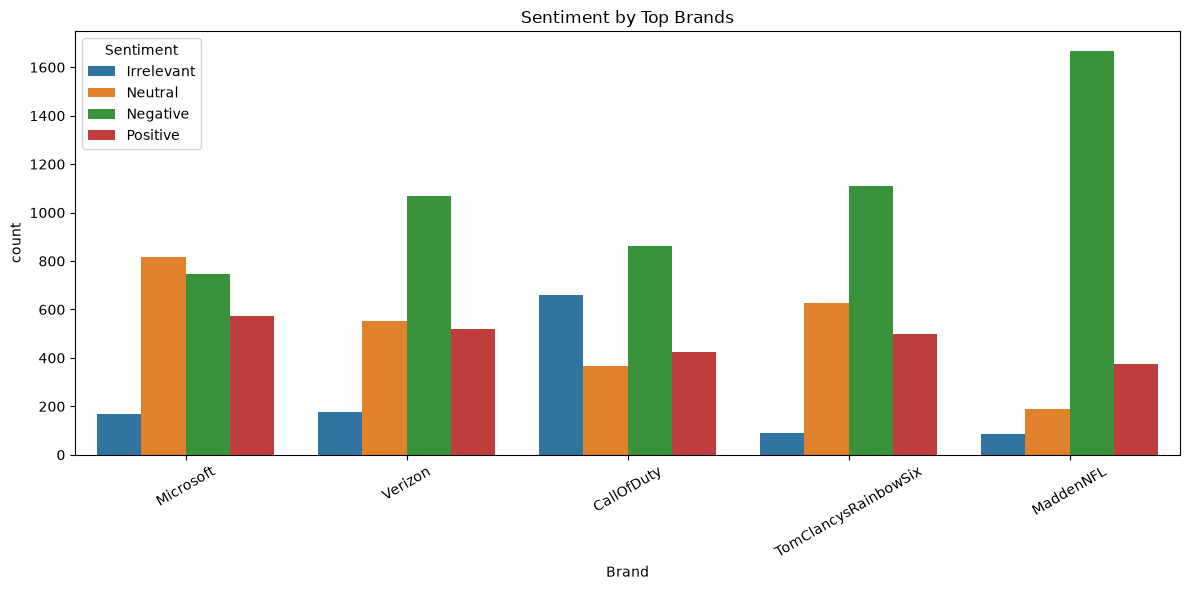

In [9]:
top5 = df["Brand"].value_counts().head(5).index

filtered = df[df["Brand"].isin(top5)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered,
    x="Brand",
    hue="Sentiment"
)

plt.title("Sentiment by Top Brands")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("sentiment_by_brand.png")
plt.show()

## Positive word cloud

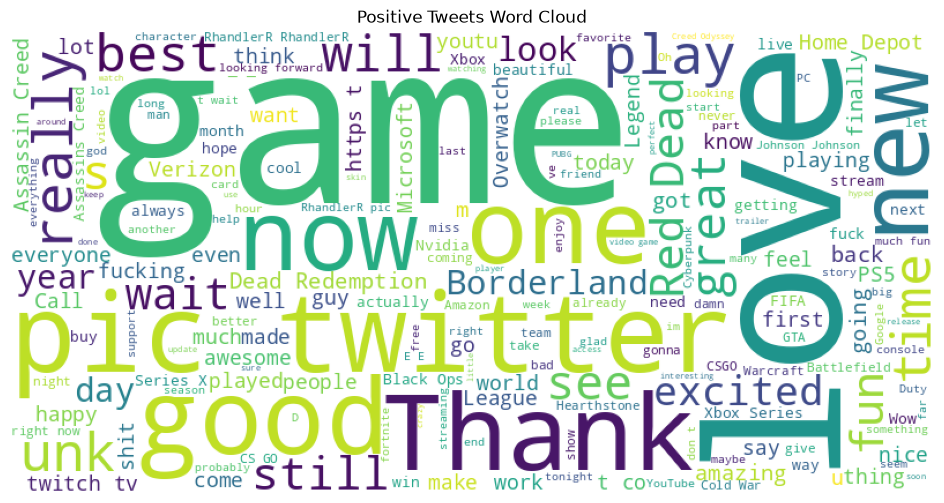

In [10]:
positive = " ".join(
    df[df["Sentiment"]=="Positive"]["Tweet"]
)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")

plt.title("Positive Tweets Word Cloud")

plt.savefig("wordcloud_positive.png")

plt.show()

## Negative Word Cloud

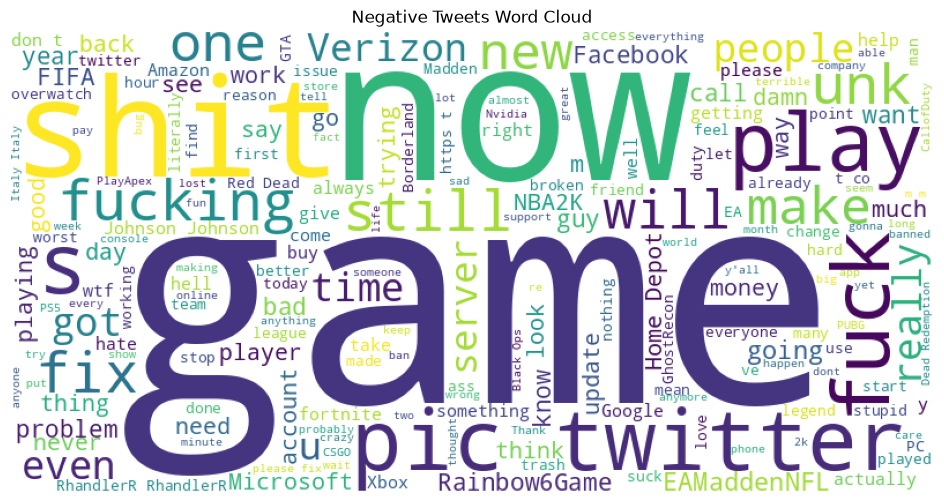

In [11]:
negative = " ".join(
    df[df["Sentiment"]=="Negative"]["Tweet"]
)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")

plt.title("Negative Tweets Word Cloud")

plt.savefig("wordcloud_negative.png")

plt.show()